### 合并数据

* pandas.concat(objs, axis=0, join='outer', ignore_index=False, keys=None, levels=None, names=None, verify_integrity=False, sort=False, copy=True)

In [1]:
import numpy as np
import pandas as pd

#### 横向堆叠合并数据
* 当axis=1的时候，concat做行对齐，然后将不同列名称的两张或多张表合并。
* 当两个表索引不完全一样时，可以使用join参数选择是内连接还是外连接。
1. 在内连接的情况下仅仅返回索引重叠部分
2. 在外链接的情况下，则显示索引的并集部分数据，不足的地方使用空值填补。
* 当两张表完全一样时，不论join的参数为何，都是按照x轴拼接。

<img src=pic/concat_h.png width=50% />

In [2]:
detail = pd.read_excel('data/meal_order_detail.xlsx')
order = pd.read_table('data/meal_order_info.csv',sep = ',',encoding = 'gbk')
user = pd.read_excel('data/users.xlsx')
df1 = detail.iloc[:,:10] ##取出detail1的前10列数据
df2 = detail.iloc[:,10:] ##取出detail1的后9列数据
print('合并df1的大小为%s，df2的大小为%s。'%(df1.shape,df2.shape))
print('外连接合并后的数据框大小为：',pd.concat([df1,df2],axis=1,join='inner').shape)
print('内连接合并后的数据框大小为：',pd.concat([df1,df2],axis=1,join='outer').shape)

合并df1的大小为(2779, 10)，df2的大小为(2779, 9)。
外连接合并后的数据框大小为： (2779, 19)
内连接合并后的数据框大小为： (2779, 19)


#### 纵向堆叠合并数据
* 使用concat函数时，在默认情况下，即axis=0时，concat做列对齐，将不同行索引的两张或多张表纵向合并。
* 在两张表的列名并不完全相同的情况下
1. join参数取值为inner时，返回的仅仅是列名交集所代表的列
2. 取值为outer时，返回的是两者列名的并集所代表的列

* 不论join参数取值是inner或者outer，结果都是将两个表完全按照Y轴拼接起来
<img src=pic/concat_v.png width=30% />

In [3]:
df3 = detail.iloc[:1500,:] ##取出detail1前1500行数据
df4 = detail.iloc[1500:,:] ##取出detail1的1500后的数据
print('合并df3的大小为%s，df4的大小为%s。'%(df3.shape,df4.shape))
print('内连接纵向合并后的数据框大小为：',pd.concat([df3,df4],axis=0,join='inner').shape)
print('外连接纵向合并后的数据框大小为：',pd.concat([df3,df4],axis=0,join='outer').shape)

合并df3的大小为(1500, 19)，df4的大小为(1279, 19)。
内连接纵向合并后的数据框大小为： (2779, 19)
外连接纵向合并后的数据框大小为： (2779, 19)


* 使用append实现纵向堆叠两张列名完全一致的表

In [4]:
df3.append(df4).shape

(2779, 19)

#### 主键合并
* 类似于SQL中的join，针对两张包含不同字段的表，将其根据某几个字段一一对应拼接起来，结果集的列数为两个原数据的列数减去连接键的数量。
<img src=pic/concat_key.png width=50% />

* pandas.merge(left, right, how='inner', on=None, left_on=None, right_on=None, left_index=False, right_index=False, sort=False, suffixes=('_x', '_y'), copy=True, indicator=False)

<img src=pic/concat_key_w.png width=60% />

In [5]:
detail['order_id']

0        415
1        681
2       1011
3        392
4        429
        ... 
2774     512
2775     534
2776     537
2777     618
2778     460
Name: order_id, Length: 2779, dtype: int64

In [6]:
order['info_id']

0      417
1      301
2      413
3      415
4      392
      ... 
940    641
941    672
942    692
943    647
944    570
Name: info_id, Length: 945, dtype: int64

In [7]:
## 订单详情表和订单信息表都有订单编号
##在订单详情表中为order_id，在订单信息表中为info_id
order_detail = pd.merge(detail,order,left_on='order_id',right_on = 'info_id')
print('detail1订单详情表的原始形状为：',detail.shape)
print('order订单信息表的原始形状为：',order.shape)
print('订单详情表和订单信息表主键合并后的形状为：',order_detail.shape)

detail1订单详情表的原始形状为： (2779, 19)
order订单信息表的原始形状为： (945, 21)
订单详情表和订单信息表主键合并后的形状为： (2779, 40)


In [8]:
order_detail['info_id']

0        415
1        415
2        415
3        415
4        415
        ... 
2774    1029
2775    1069
2776    1069
2777    1069
2778    1064
Name: info_id, Length: 2779, dtype: int64

In [9]:
order_detail['order_id']

0        415
1        415
2        415
3        415
4        415
        ... 
2774    1029
2775    1069
2776    1069
2777    1069
2778    1064
Name: order_id, Length: 2779, dtype: int64

In [10]:
order_detail.columns

Index(['detail_id', 'order_id', 'dishes_id', 'logicprn_name',
       'parent_class_name', 'dishes_name', 'itemis_add', 'counts', 'amounts',
       'cost', 'place_order_time', 'discount_amt', 'discount_reason',
       'kick_back', 'add_inprice', 'add_info', 'bar_code', 'picture_file',
       'emp_id_x', 'info_id', 'emp_id_y', 'number_consumers', 'mode',
       'dining_table_id', 'dining_table_name', 'expenditure', 'dishes_count',
       'accounts_payable', 'use_start_time', 'check_closed', 'lock_time',
       'cashier_id', 'pc_id', 'order_number', 'org_id', 'print_doc_bill_num',
       'lock_table_info', 'order_status', 'phone', 'name'],
      dtype='object')

* 也可以使用join方法实现，但要求两个主键的名字必须相同。
* pandas.DataFrame.join(self, other, on=None, how='left', lsuffix='', rsuffix='', sort=False)

In [11]:
order.rename({'info_id':'order_id'},axis='columns',inplace=True)
order_detail_ex= detail.join(order,on='order_id',rsuffix='_fromright')
print('订单详情表和订单信息表join合并后的形状为：',order_detail.shape)

订单详情表和订单信息表join合并后的形状为： (2779, 40)


In [12]:
order_detail_ex.columns

Index(['detail_id', 'order_id', 'dishes_id', 'logicprn_name',
       'parent_class_name', 'dishes_name', 'itemis_add', 'counts', 'amounts',
       'cost', 'place_order_time', 'discount_amt', 'discount_reason',
       'kick_back', 'add_inprice', 'add_info', 'bar_code', 'picture_file',
       'emp_id', 'order_id_fromright', 'emp_id_fromright', 'number_consumers',
       'mode', 'dining_table_id', 'dining_table_name', 'expenditure',
       'dishes_count', 'accounts_payable', 'use_start_time', 'check_closed',
       'lock_time', 'cashier_id', 'pc_id', 'order_number', 'org_id',
       'print_doc_bill_num', 'lock_table_info', 'order_status', 'phone',
       'name'],
      dtype='object')

##### 某些特征在一张表上是完整的，而在另一张表上的数据则是缺失的。

In [13]:
##建立两个字典，除了ID外，别的特征互补
dict1 = {'ID':[1,2,3,4,5,6,7,8,9],
         'System':['win10','win10',np.nan,'win10',np.nan,np.nan,'win7','win7','win8'],
         'cpu':['i7','i5',np.nan,'i7',np.nan,np.nan,'i5','i5','i4']}

dict2 = {'ID':[1,2,3,4,5,6,7,8,9],
         'System':[np.nan,np.nan,'win7',np.nan,'win8','win7',np.nan,np.nan,np.nan],
         'cpu':[np.nan,np.nan,'i3',np.nan,'i7','i5',np.nan,np.nan,'i3']}

## 转换两个字典为DataFrame
df5 = pd.DataFrame(dict1)
df6 = pd.DataFrame(dict2)
print(df5)
print(df6)
print('经过重叠合并后的数据为：\n',df5.combine_first(df6))

   ID System  cpu
0   1  win10   i7
1   2  win10   i5
2   3    NaN  NaN
3   4  win10   i7
4   5    NaN  NaN
5   6    NaN  NaN
6   7   win7   i5
7   8   win7   i5
8   9   win8   i4
   ID System  cpu
0   1    NaN  NaN
1   2    NaN  NaN
2   3   win7   i3
3   4    NaN  NaN
4   5   win8   i7
5   6   win7   i5
6   7    NaN  NaN
7   8    NaN  NaN
8   9    NaN   i3
经过重叠合并后的数据为：
    ID System cpu
0   1  win10  i7
1   2  win10  i5
2   3   win7  i3
3   4  win10  i7
4   5   win8  i7
5   6   win7  i5
6   7   win7  i5
7   8   win7  i5
8   9   win8  i4


### 检测与处理重复
#### 记录重复

In [14]:
##方法一:代码冗长
##定义去重函数
def delRep(list1):
    list2=[]
    for i in list1:
        if i not in list2:
            list2.append(i)
    return list2 
## 去重
dishes=list(detail['dishes_name']) ##将dishes_name从数据框中提取出来
print('去重前菜品总数为：',len(dishes)) 
dish = delRep(dishes) ##使用自定义的去重函数去重
print('方法一去重后菜品总数为：',len(dish))

去重前菜品总数为： 2779
方法一去重后菜品总数为： 154


In [15]:
##方法二:数据排列发生改变
print('去重前菜品总数为：',len(dishes)) 
dish_set = set(dishes) ##利用set的特性去重
print('方法二去重后菜品总数为：',len(dish_set))

去重前菜品总数为： 2779
方法二去重后菜品总数为： 154


* pandas提供了一个名为drop_duplicates的去重方法。
* 该方法只对DataFrame或者Series类型有效。这种方法不会改变数据原始排列，并且兼具代码简洁和运行稳定的特点。
* 该方法不仅支持单一特征的数据去重，还能够依据DataFrame的其中一个或者几个特征进行去重操作。
* pandas.DataFrame(Series).drop_duplicates(self, subset=None, keep='first', inplace=False)

<img src=pic/dropduplicates.png width=50% />

In [16]:
##对dishes_name去重
dishes_name = detail['dishes_name'].drop_duplicates()
print('drop_duplicates方法去重之后菜品总数为：',len(dishes_name))

drop_duplicates方法去重之后菜品总数为： 154


In [17]:
#依照多列去重
print('去重之前订单详情表的形状为：', detail.shape)
shapeDet = detail.drop_duplicates(subset = ['dishes_name','emp_id']).shape
print('依照菜品，会员编号去重之后订单详情表大小为:', shapeDet)

去重之前订单详情表的形状为： (2779, 19)
依照菜品，会员编号去重之后订单详情表大小为: (2730, 19)


#### 特征去重
##### 可以通过计算相似度，将相似度为1的特征去除一个，计算方法为corr，参数可设置，spearman，kendall，默认为pearson
* 缺点：只能处理数值型数据

In [18]:
detail

,detail_id,order_id,dishes_id,logicprn_name,parent_class_name,dishes_name,itemis_add,counts,amounts,cost,place_order_time,discount_amt,discount_reason,kick_back,add_inprice,add_info,bar_code,picture_file,emp_id
0,2952,415,610071,NaN,NaN,42度海之蓝,0,1,99,NaN,2016-08-01 13:07:10,NaN,NaN,NaN,0,NaN,NaN,caipu/401004.jpg,1166
1,5765,681,610071,NaN,NaN,42度海之蓝,0,3,99,NaN,2016-08-05 20:28:41,NaN,NaN,NaN,0,NaN,NaN,caipu/401004.jpg,1183
2,2533,1011,610071,NaN,NaN,42度海之蓝,0,1,99,NaN,2016-08-09 20:50:20,NaN,NaN,NaN,0,NaN,NaN,caipu/401004.jpg,1255
3,2670,392,609947,NaN,NaN,北冰洋汽水,0,1,5,NaN,2016-08-01 13:02:29,NaN,NaN,NaN,0,NaN,NaN,caipu/404003.jpg,1094
4,3069,429,609947,NaN,NaN,北冰洋汽水,0,1,5,NaN,2016-08-01 13:24:10,NaN,NaN,NaN,0,NaN,NaN,caipu/404003.jpg,1452
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2774,3985,512,610009,NaN,NaN,黑米恋上葡萄,0,1,33,NaN,2016-08-08 19:28:59,NaN,NaN,NaN,0,NaN,NaN,caipu/601003.jpg,1122
2775,4171,534,610009,NaN,NaN,黑米恋上葡萄,0,1,33,NaN,2016-08-09 18:06:03,NaN,NaN,NaN,0,NaN,NaN,caipu/601003.jpg,1132
2776,4208,537,610009,NaN,NaN,黑米恋上葡萄,0,1,33,NaN,2016-08-09 20:47:33,NaN,NaN,NaN,0,NaN,NaN,caipu/601003.jpg,1378
2777,5096,618,610009,NaN,NaN,黑米恋上葡萄,0,1,33,NaN,2016-08-09 21:06:48,NaN,NaN,NaN,0,NaN,NaN,caipu/601003.jpg,1123


In [19]:
corrDet = detail[['counts','amounts']].corr(method='kendall')
print('销量和售价的kendall相似度为：\n',corrDet)

销量和售价的kendall相似度为：
            counts   amounts
counts   1.000000 -0.253092
amounts -0.253092  1.000000


In [20]:
corrDet1 = detail[['dishes_name','counts','amounts']].corr(method='pearson')
print('菜品名称，销量和售价的pearson相似度为：\n',corrDet1)

菜品名称，销量和售价的pearson相似度为：
            counts   amounts
counts   1.000000 -0.174648
amounts -0.174648  1.000000


##### 使用equals方法

In [21]:
##定义求取特征是否完全相同的矩阵的函数
def FeatureEquals(df):
    dfEquals=pd.DataFrame([],columns=df.columns,index=df.columns)
    for i in df.columns:
       for j in df.columns:
           dfEquals.loc[i,j]=df.loc[:,i].equals(df.loc[:,j])
    return dfEquals
## 应用上述函数
detEquals=FeatureEquals(detail)
print('detail的特征相等矩阵的前5行5列为：\n',detEquals.iloc[:5,:5])

detail的特征相等矩阵的前5行5列为：
                   detail_id order_id dishes_id logicprn_name parent_class_name
detail_id              True    False     False         False             False
order_id              False     True     False         False             False
dishes_id             False    False      True         False             False
logicprn_name         False    False     False          True              True
parent_class_name     False    False     False          True              True


In [22]:
##遍历所有数据
lenDet = detEquals.shape[0]
dupCol = []
for k in range(lenDet):
    for l in range(k+1,lenDet):
        if detEquals.iloc[k,l] & (detEquals.columns[l] not in dupCol):
            dupCol.append(detEquals.columns[l])
##进行去重操作
print('需要删除的列为：',dupCol)
detail.drop(dupCol,axis=1,inplace=True)
print('删除多余列后detail的特征数目为：',detail.shape[1])

需要删除的列为： ['parent_class_name', 'cost', 'discount_amt', 'discount_reason', 'kick_back', 'add_info', 'bar_code', 'add_inprice']
删除多余列后detail的特征数目为： 11


### 缺失值

In [23]:
print('detail每个特征缺失的数目为：\n',detail.isnull().sum())
print('detail每个特征非缺失的数目为：\n',detail.notnull().sum())

detail每个特征缺失的数目为：
 detail_id              0
order_id               0
dishes_id              0
logicprn_name       2779
dishes_name            0
itemis_add             0
counts                 0
amounts                0
place_order_time       0
picture_file           0
emp_id                 0
dtype: int64
detail每个特征非缺失的数目为：
 detail_id           2779
order_id            2779
dishes_id           2779
logicprn_name          0
dishes_name         2779
itemis_add          2779
counts              2779
amounts             2779
place_order_time    2779
picture_file        2779
emp_id              2779
dtype: int64


#### 删除记录或特征
* pandas.DataFrame.dropna(self, axis=0, how='any', thresh=None, subset=None, inplace=False)
<img src=pic/dropna.png width=60% />

In [24]:
print('去除缺失的列前detail的形状为：', detail.shape)
print('去除缺失的列后detail的形状为：', detail.dropna(axis = 1,how ='any').shape)

去除缺失的列前detail的形状为： (2779, 11)
去除缺失的列后detail的形状为： (2779, 10)


#### 替换法
* 是指用一个特定的值替换缺失值。
* 特征可分为数值型和类别型，两者出现缺失值时的处理方法也是不同的。
1. 缺失值所在特征为数值型时，通常利用其均值、中位数和众数等描述其集中趋势的统计量来代替缺失值。
2. 缺失值所在特征为类别型时，则选择使用众数来替换缺失值。
* pandas.DataFrame.fillna(value=None, method=None, axis=None, inplace=False, limit=None)
<img src=pic/fillna.png width=60% />

In [25]:
detail = detail.fillna(-99)
print('detail每个特征缺失的数目为：\n',detail.isnull().sum())

detail每个特征缺失的数目为：
 detail_id           0
order_id            0
dishes_id           0
logicprn_name       0
dishes_name         0
itemis_add          0
counts              0
amounts             0
place_order_time    0
picture_file        0
emp_id              0
dtype: int64


#### 插值法
* 删除：简单易行，但会引起数据结构变动，样本减少
* 替换：难度低，但会影响数据标准差，导致信息量变动
* 插值
1. 线性插值：通过线性方程求出缺失值
1. 多项式插值：用已知值拟合多项式，再求缺失值，常见的为拉格朗日插值和牛顿插值等
1. 样条插值：以可变样条来做出一条经过一系列点的光滑曲线的插值方法。插值样条由一系列多项式组成，每一个多项式都有相邻两个数据点决定，这样可以保证两个相邻多项式及其导数在连接处连续。

* 线性插值法只在自变量和因变量为线性关系的情况下拟合才较为出色。

In [26]:
from scipy.interpolate import interp1d
x=np.array([1,2,3,4,5,8,9,10]) ##创建自变量x
y1=np.array([2,8,18,32,50,128,162,200]) ##创建因变量y1
y2=np.array([3,5,7,9,11,17,19,21]) ##创建因变量y2
LinearInsValue1 = interp1d(x,y1,kind='linear') ##线性插值拟合x,y1
LinearInsValue2 = interp1d(x,y2,kind='linear') ##线性插值拟合x,y2
print('当x为6、7时，使用线性插值y1为：',LinearInsValue1([6,7]))
print('当x为6、7时，使用线性插值y2为：',LinearInsValue2([6,7]))

当x为6、7时，使用线性插值y1为： [ 76. 102.]
当x为6、7时，使用线性插值y2为： [13. 15.]


* 拉格朗日插值

In [27]:
from scipy.interpolate import lagrange
LargeInsValue1 = lagrange(x,y1) ##拉格朗日插值拟合x,y1
LargeInsValue2 = lagrange(x,y2) ##拉格朗日插值拟合x,y2
print('当x为6,7时，使用拉格朗日插值y1为：',LargeInsValue1([6,7]))
print('当x为6,7时，使用拉格朗日插值y2为：',LargeInsValue2([6,7]))

当x为6,7时，使用拉格朗日插值y1为： [72. 98.]
当x为6,7时，使用拉格朗日插值y2为： [13. 15.]


* 大多数情况下，多项式插值和样条插值是较为合适的选择

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
##样条插值拟合x,y1
f1 = interp1d(x, y1)
##样条插值拟合x,y2
f2 = interp1d(x, y2)
xnew = np.arange(6, 8)
ynew1 = f1(xnew)
ynew2 = f2(xnew)
print('当x为6,7时，使用样条插值y1为：',ynew1)
print('当x为6,7时，使用样条插值y2为：',ynew2)

当x为6,7时，使用样条插值y1为： [ 76. 102.]
当x为6,7时，使用样条插值y2为： [13. 15.]


### 异常值
* 异常值是指数据中个别值的数值明显偏离其余的数值，有时也称为离群点，检测异常值就是检验数据中是否有录入错误以及是否含有不合理的数据。
* 异常值的存在对数据分析十分危险，如果计算分析过程的数据有异常值，那么会对结果会产生不良影响，从而导致分析结果产生偏差乃至错误。
* 常用的异常值检测主要为3σ原则和箱线图分析两种方法。


1. 3σ原则又称为拉依达法则。该法则就是先假设一组检测数据只含有随机误差，对原始数据进行计算处理得到标准差，然后按一定的概率确定一个区间，认为误差超过这个区间的就属于异常值。
* 这种判别处理方法仅适用于对正态或近似正态分布的样本数据进行处理，如下表所示，其中σ代表标准差，μ代表均值，x=μ为图形的对称轴。
* 数据的数值分布几乎全部集中在区间(μ-3σ,μ+3σ)内，超出这个范围的数据仅占不到0.3%。故根据小概率原理，可以认为超出3σ的部分数据为异常数据。
<img src=pic/3c.png width=30% />

2. 箱线图

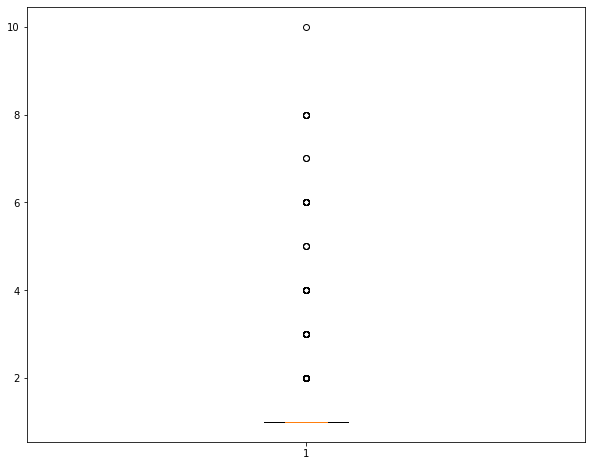

销售量数据异常值个数为： 141
销售量数据异常值的最大值为： 10
销售量数据异常值的最小值为： 2


In [29]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,8)) 
p = plt.boxplot(detail['counts'].values,notch=True)   ##画出箱线图
outlier1 = p['fliers'][0].get_ydata()   ##fliers为异常值的标签
plt.savefig('gen_pics/菜品异常数据识别.png')
plt.show()
print('销售量数据异常值个数为：',len(outlier1))
print('销售量数据异常值的最大值为：',max(outlier1))
print('销售量数据异常值的最小值为：',min(outlier1))

### 标准化
#### 离差标准化
<img src=pic/离差标准化.png width=20% />
缺点：若数据中的某个数值很大，则离差标准化的值就会接近于0，并且相互之间的差别不大。且将来遇到超出当前[min, max]的情况，系统将会报错。

In [30]:
## 自定义离差标准化函数
def MinMaxScale(data):
    data=(data-data.min())/(data.max()-data.min())
    return data
##对菜品订单表售价和销量做离差标准化
data1=MinMaxScale(detail['counts'])
data2=MinMaxScale(detail ['amounts'])
data3=pd.concat([data1,data2],axis=1)
print('离差标准化之前销量和售价数据为：\n',
    detail[['counts','amounts']].head())
print('离差标准化之后销量和售价数据为：\n',data3.head())

离差标准化之前销量和售价数据为：
    counts  amounts
0       1       99
1       3       99
2       1       99
3       1        5
4       1        5
离差标准化之后销量和售价数据为：
      counts   amounts
0  0.000000  0.553672
1  0.222222  0.553672
2  0.000000  0.553672
3  0.000000  0.022599
4  0.000000  0.022599


#### 标准差标准化
<img src=pic/标准差标准化.png width=15% />受数据分布的影响较小

In [31]:
def StandardScaler(data):
    data=(data-data.mean())/data.std()
    return data
##对菜品订单表售价和销量做标准化
data4=StandardScaler(detail['counts'])
data5=StandardScaler(detail['amounts'])
data6=pd.concat([data4,data5],axis=1)
print('标准差标准化之前销量和售价数据为：\n',
    detail[['counts','amounts']].head())
print('标准差标准化之后销量和售价数据为：\n',data6.head())

标准差标准化之前销量和售价数据为：
    counts  amounts
0       1       99
1       3       99
2       1       99
3       1        5
4       1        5
标准差标准化之后销量和售价数据为：
      counts   amounts
0 -0.177784  1.457890
1  3.020028  1.457890
2 -0.177784  1.457890
3 -0.177784 -1.095864
4 -0.177784 -1.095864


#### 小数定标标准化数据
<img src=pic/小数定标标准化.png width=15% />
这种方法通过移动数据的小数点位置来进行标准化。相比于前两种，适用程度适中。取值 [-1，1]

In [32]:
##自定义小数定标差标准化函数
def DecimalScaler(data):
    data=data/10**np.ceil(np.log10(data.abs().max()))
    return data
##对菜品订单表售价和销量做标准化
data7=DecimalScaler(detail['counts'])
data8=DecimalScaler(detail['amounts'])
data9=pd.concat([data7,data8],axis=1)
print('小数定标标准化之前的销量和售价数据：\n',
    detail[['counts','amounts']].head())
print('小数定标标准化之后的销量和售价数据：\n',data9.head())

小数定标标准化之前的销量和售价数据：
    counts  amounts
0       1       99
1       3       99
2       1       99
3       1        5
4       1        5
小数定标标准化之后的销量和售价数据：
    counts  amounts
0     0.1    0.099
1     0.3    0.099
2     0.1    0.099
3     0.1    0.005
4     0.1    0.005


### 哑变量处理
<img src=pic/dummies.png width=15% />
pandas.get_dummies(data, prefix=None, prefix_sep='_', dummy_na=False, columns=None, sparse=False, drop_first=False)
<img src=pic/get_dummies.png width=60% />

In [33]:
data=detail.loc[0:5,'dishes_name']   ##抽取部分数据做演示
print('哑变量处理前的数据为：\n',data)
print('哑变量处理后的数据为：\n',pd.get_dummies(data))

哑变量处理前的数据为：
 0     42度海之蓝
1     42度海之蓝
2     42度海之蓝
3     北冰洋汽水 
4     北冰洋汽水 
5     北冰洋汽水 
Name: dishes_name, dtype: object
哑变量处理后的数据为：
     42度海之蓝   北冰洋汽水 
0        1        0
1        1        0
2        1        0
3        0        1
4        0        1
5        0        1


### 离散化连续性数据

某些模型算法，要求数据是离散的，此时就需要将连续型特征（数值型）变换成离散型特征（类别型）。
连续特征的离散化就是在数据的取值范围内设定若干个离散的划分点，将取值范围划分为一些离散化的区间，最后用不同的符号或整数值代表落在每个子区间中的数据值。
因此离散化涉及两个子任务，即确定分类数以及如何将连续型数据映射到这些类别型数据上。其原理如图。

<img src=pic/离散化.png width=30% />

#### 等宽法
pandas.cut(x, bins, right=True, labels=None, retbins=False, precision=3, include_lowest=False)
<img src=pic/cut.png width=60% />
等宽法离散化对数据分布具有较高要求，若数据分布不均匀，那么各个类的数目也会变得非常不均匀，有些区间包含许多数据，而有些区间的数据极少。

In [34]:
price = pd.cut(detail['amounts'],5)
print('离散化后5条记录售价分布为：\n' ,price.value_counts())

离散化后5条记录售价分布为：
 (0.823, 36.4]     1488
(36.4, 71.8]       885
(71.8, 107.2]      233
(142.6, 178.0]     130
(107.2, 142.6]      43
Name: amounts, dtype: int64


#### 等频法
等频离散化避免了数据分布不均匀的问题，但同时也有可能将数值非常接近的两个值分到不同的区间以满足每个区间对数据个数的要求。


In [35]:
##自定义等频法离散化函数
def SameRateCut(data,k):
    w=data.quantile(np.arange(0,1+1.0/k,1.0/k))
    data=pd.cut(data,w)
    return data
result=SameRateCut(detail['amounts'],5).value_counts()   ##菜品售价等频法离散化
print('菜品数据等频法离散化后各个类别数目分布状况为：','\n',result)

菜品数据等频法离散化后各个类别数目分布状况为： 
 (39.0, 58.0]     580
(18.0, 32.0]     564
(1.0, 18.0]      530
(58.0, 178.0]    530
(32.0, 39.0]     515
Name: amounts, dtype: int64


#### 基于聚类分析的方法

一维聚类的方法包括两个步骤：
将连续型数据用聚类算法（如K-Means算法等）进行聚类。
处理聚类得到的簇，将合并到一个簇的连续型数据做同一标记。
聚类分析的离散化方法需要用户指定簇的个数，用来决定产生的区间数。
k-Means聚类分析的离散化方法可以很好地根据现有特征的数据分布状况进行聚类，但是由于k-Means算法本身的缺陷，用该方法进行离散化时依旧需要指定离散化后类别的数目。此时需要配合聚类算法评价方法，找出最优的聚类簇数目。